<a href="https://colab.research.google.com/github/raunakdwivedi03/MLProjects-23/blob/main/IMDB_Dataset_of_50K_Movie_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_csv('/content/IMDB Dataset.csv')

In [14]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [15]:
df.shape

(50000, 2)

In [16]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

steps of
1. data gathering

2.cleaning



In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [18]:
df.duplicated().sum()

np.int64(418)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [21]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


#cleaning


In [22]:
#lowercase
df.head()
df['review']= df['review'].str.lower()

In [23]:
#remove wide spcaes
df['review']=df['review'].str.strip()

In [24]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [25]:
#remove regular tags
import re
def remove_html(data):
  data=re.sub(r'<.*?>','',data)
  return data

In [26]:
remove_html('<p>my name is raunak</p><br><img>')

'my name is raunak'

In [27]:
#remove html tags
df['review']=df['review'].apply(remove_html)

In [28]:
df['review']


,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. the filming tec...
2,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is..."
...,...
49995,i thought this movie did a down right good job...
49996,"bad plot, bad dialogue, bad acting, idiotic di..."
49997,i am a catholic taught in parochial elementary...
49998,i'm going to have to disagree with the previou...


In [29]:
df['review'][0]

"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. em city is home to many..aryans, muslims, gangstas, latinos, christians, italians, irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.i would say the main appeal of the show is due to the fact that it goes where other shows wo

In [30]:
# yh na krke ham tags ko replcae kr skte hai space se
df['review']=df['review'].str.replace(r'<.*?>','')
df['review']

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. the filming tec...
2,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is..."
...,...
49995,i thought this movie did a down right good job...
49996,"bad plot, bad dialogue, bad acting, idiotic di..."
49997,i am a catholic taught in parochial elementary...
49998,i'm going to have to disagree with the previou...


In [31]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [32]:
#removing urls
def remove_url(data):
  data=re.sub(r'https://\S+|www\.\S+','',data)
  return data

In [33]:
remove_url('to register on the www.leetcode.com ')

'to register on the  '

In [34]:
df['review']=df['review'].apply(remove_url)

In [35]:
df['review'].head()

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. the filming tec...
2,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is..."


In [36]:
#code to remove the url

df['review']=df['review'].str.replace(r'https://\S+|www\.\S+','')

In [37]:
df['review']

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. the filming tec...
2,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is..."
...,...
49995,i thought this movie did a down right good job...
49996,"bad plot, bad dialogue, bad acting, idiotic di..."
49997,i am a catholic taught in parochial elementary...
49998,i'm going to have to disagree with the previou...


In [38]:
#code to contain a url
df['review'] = (
    df['review']
    .astype(str)
    .str.contains(r'https?://\S+|www\.\S+', '')
)

In [39]:
(df['review'].astype(str))

,review
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


In [40]:
df.head()

,review,sentiment
0,False,positive
1,False,positive
2,False,positive
3,False,negative
4,False,positive


In [41]:
#expending the abbrevations
import re

def remove_abb(data):
    text = {
        "ain't": "am not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "could've": "could have",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "i'd": "i would",
        "i'll": "i will",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "should've": "should have",
        "shouldn't": "should not",
        "that's": "that is",
        "there's": "there is",
        "they'd": "they would",
        "they'll": "they will",
        "they're": "they are",
        "they've": "they have",
        "wasn't": "was not",
        "we'd": "we would",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you'd": "you would",
        "you'll": "you will",
        "you're": "you are",
        "you've": "you have",

        # Encoding issues (from your dataset/images)
        "don\x89ûªt": "do not",
        "can\x89ûªt": "cannot",
        "i\x89ûªm": "i am",
        "it\x89ûªs": "it is",
        "doesn\x89ûªt": "does not",
        "here\x89ûªs": "here is",
        "who\x89ûªs": "who is",
        "you\x89ûªre": "you are",
        "you\x89ûªve": "you have",
        "i\x89ûªve": "i have",
        "wouldn\x89ûªt": "would not",
        "weren\x89ûªt": "were not"
    }

    return contractions.get(data.lower(), data)



In [42]:
from textblob import TextBlob

text="hi i can drve a car"
TextBlob(text).correct().string

'hi i can drove a car'

In [43]:
from textblob import TextBlob

def spelling_correction(text):
    text = str(text)   # safety line
    return str(TextBlob(text).correct())

In [44]:
df['review'].apply(spelling_correction)

,review
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


#Pucntuation-->
Punctuations wo symbols hote hain jo sentence ko clear, readable aur meaningful banate hain.

Jaise bolne me pause hota hai,
waise likhne me punctuation marks hote hain.



In [45]:
# Punctuations
#remove string


In [46]:
import string

def remove_puc(text):
    text = str(text)   # safety
    for i in string.punctuation:
        text = text.replace(i, '')
    return text

In [47]:
df['review'] = df['review'].apply(remove_puc)
df['review']

,review
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


In [48]:
#remove special chacracter --> $ @ yh sb
import re

def remove_special_char(text):
    return re.sub(r'[^a-zA-Z\s]', '', str(text))


In [49]:
df['review'] = df['review'].apply(remove_special_char)


In [50]:
df['review']

,review
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


#Pre Processing

Data preprocessing ek aisi process hai jisme raw data ko clean aur transform kiya jata hai, taki machine learning models ya analysis ke liye usable aur accurate ban sake.


In [51]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [52]:
from nltk.tokenize import word_tokenize

In [53]:
df['tokenized_review'] = df['review'].apply(word_tokenize)

In [54]:
df['review'] = df['review'].astype(str)

In [55]:
df['review'] = df['review'].astype(str)

# Tokenization function
def clean_tokenize(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation
    tokens = text.split()  # Split by whitespace
    return tokens

# Apply tokenization
df['tokenized_review'] = df['review'].apply(clean_tokenize)

# Check result
df['tokenized_review'] = df['review'].astype(str).apply(clean_tokenize)


In [56]:
df.head()

,review,sentiment,tokenized_review
0,False,positive,[false]
1,False,positive,[false]
2,False,positive,[false]
3,False,negative,[false]
4,False,positive,[false]


In [57]:
#stopword removal
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [58]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [59]:
def remove_stopwords(text):

  l=[]
  for word in text:
    if word in stopwords.words('english'):
      l.append(word)

  return l

  stop_words = set(stopwords.words('english'))

In [60]:
df['tokenized_review']=df['tokenized_review'].apply(remove_stopwords)

In [61]:
df['tokenized_review']

,tokenized_review
0,[]
1,[]
2,[]
3,[]
4,[]
...,...
49995,[]
49996,[]
49997,[]
49998,[]


#EDA and Feature Engineering


EDA --> EDA = Data ko dekhna, samajhna, aur patterns nikaalna




In [62]:
#distribution of text length / word count
#common unigrams/bigrams/trigrams
#wordcloud

In [63]:
df.head()

,review,sentiment,tokenized_review
0,False,positive,[]
1,False,positive,[]
2,False,positive,[]
3,False,negative,[]
4,False,positive,[]


In [ ]:
df['char_lenght']=df['tokenized_review'].apply(len)

In [65]:
df['char_lenght']

,char_lenght
0,0
1,0
2,0
3,0
4,0
...,...
49995,0
49996,0
49997,0
49998,0


In [66]:
import seaborn as sns


/tmp/ipython-input-4272395065.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['char_lenght'])
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:2496: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


<Axes: xlabel='char_lenght', ylabel='Density'>

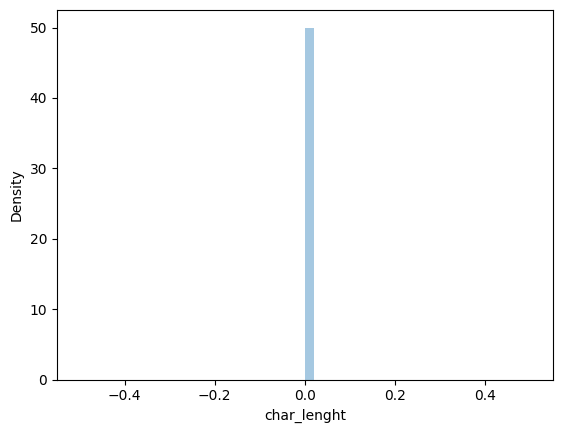

In [67]:
sns.distplot(df['char_lenght'])

In [68]:
df[df['sentiment'] == 'positive']

,review,sentiment,tokenized_review,char_lenght
0,False,positive,[],0
1,False,positive,[],0
2,False,positive,[],0
4,False,positive,[],0
5,False,positive,[],0
...,...,...,...,...
49983,False,positive,[],0
49985,False,positive,[],0
49989,False,positive,[],0
49992,False,positive,[],0


/tmp/ipython-input-3910756366.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] == 'positive']['char_lenght'])
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:2496: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


<Axes: xlabel='char_lenght', ylabel='Density'>

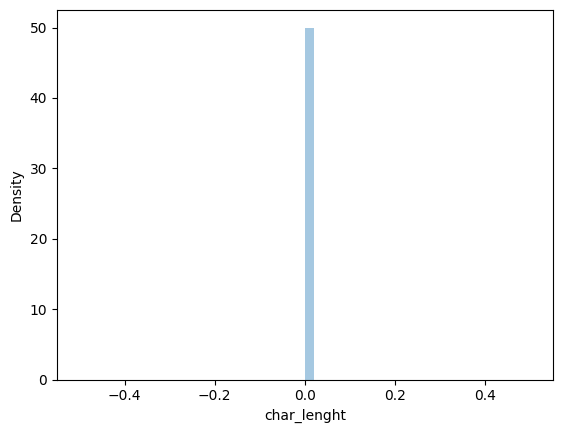

In [69]:
sns.distplot(df[df['sentiment'] == 'positive']['char_lenght'])

/tmp/ipython-input-2523275740.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] == 'negative']['char_lenght'])
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:2496: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


<Axes: xlabel='char_lenght', ylabel='Density'>

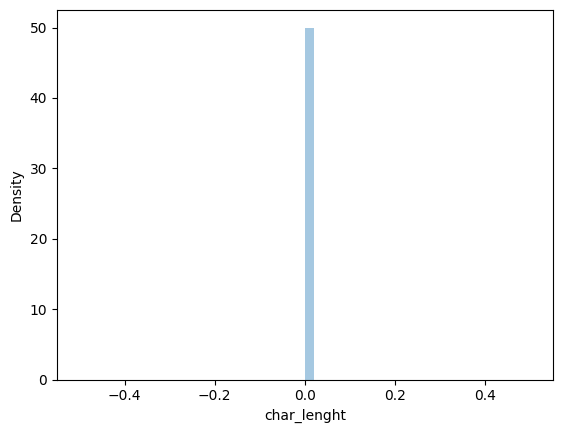

In [70]:
sns.distplot(df[df['sentiment'] == 'negative']['char_lenght'])

In [71]:
from nltk import ngrams


In [72]:
pd.Series(ngrams(df['tokenized_review'].sum(),2)).value_counts()

,count


In [73]:
pd.Series(ngrams(df['tokenized_review'].sum(),3)).value_counts()

,count


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize=(20,25))
wc = WordCloud(max_words=1600, height=800).generate(
    "".join(df[df['sentiment'] == 'positive']['review'])
)
plt.imshow(wc)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize=(20,25))
wc = WordCloud(max_words=1600, height=800).generate(
    "".join(df[df['sentiment'] == 'negative']['review'])
)
plt.imshow(wc)

#Vectorizations


In [ ]:
#BOW --> bag of words
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer(max_features=5000,ngram_range=(2,2))
bag_of_words=count_vect.fit_transform(df['review'])
bag_of_words = pd.DataFrame(bag_of_words.toarray(), columns=count_vect.get_feature_names())


In [ ]:
bag_of_words

#PCA(Principle Component Analysis)



In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca=PCA(n_components=3)
pca_result=pca.fit_transform(bag_of_words.values)

In [ ]:
pca_result.shape

In [ ]:
sns.scatter(pca_result[:,0],pca_result[:,1],hue=df['sentiment'])